In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
# 为了在打乱数据时保持结果一致，固定一个随机种子
import numpy as np
np.random.seed(42)


project_root = '/content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1'

data_raw = os.path.join(project_root, 'data', 'ISOT')

true_path = os.path.join(data_raw, 'True.csv')
fake_path = os.path.join(data_raw, 'Fake.csv')

print("正在读取 CSV 文件...")
df_true = pd.read_csv(true_path)
df_fake = pd.read_csv(fake_path)


print(f"真实新闻数量: {len(df_true)}")
print(f"虚假新闻数量: {len(df_fake)}")

# 2. 给它们打上标签 (Label)
# 机器看不懂什么是"真假"，我们规定：1 代表真新闻，0 代表假新闻
df_true['label'] = 1
df_fake['label'] = 0

# 3. 把两个表上下拼接在一起
# ignore_index=True 是为了让行号重新从 0 开始排
df_all = pd.concat([df_true, df_fake], ignore_index=True)

# 4. 洗牌 (Shuffle) ！！！
# 这一步极其关键。如果前面全是真新闻，后面全是假新闻，模型学着学着就傻了。
# frac=1 表示 100% 的数据都参与洗牌
df_all = df_all.sample(frac=1).reset_index(drop=True)

# 5. 看看拼好的表长什么样
print("\n拼接并洗牌后的数据前 5 行：")
display(df_all.head())

# (可选) 把处理好的数据存起来，以后就不用每次都拼了
# df_all.to_csv('../data/processed/isot_mixed.csv', index=False)

正在读取 CSV 文件...
真实新闻数量: 21417
虚假新闻数量: 23481

拼接并洗牌后的数据前 5 行：


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


In [ ]:
# Cell 2: Feature Engineering & Train-Test Split
from sklearn.model_selection import train_test_split

print("正在将 title 和 text 拼接成完整的输入特征...")
# 标题通常包含很强的假新闻情绪特征，正文包含语境。拼在一起效果最好。
# 加 astype(str) 是为了防止万一有空值报错
df_all['full_text'] = df_all['title'].astype(str) + " - " + df_all['text'].astype(str)

# 扔掉不需要的列（subject, date 等），释放内存。我们只要文本和标签。
df_clean = df_all[['full_text', 'label']]

print("正在切分训练集和验证集 (80% 训练, 20% 验证)...")
# 把数据集切成两份：80% 拿来训练模型，20% 拿来考试(验证)，防止模型过拟合
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_clean['full_text'].tolist(),
    df_clean['label'].tolist(),
    test_size=0.2,       # 20% 作为验证集
    random_state=42      # 保证每次切分的随机结果一模一样，方便复现
)

print(f"✅ 切分完成！")
print(f"训练集大小: {len(train_texts)} 条新闻")
print(f"验证集大小: {len(val_texts)} 条新闻")


正在将 title 和 text 拼接成完整的输入特征...
正在切分训练集和验证集 (80% 训练, 20% 验证)...
✅ 切分完成！
训练集大小: 35918 条新闻
验证集大小: 8980 条新闻


In [ ]:
# Cell 3: Tokenization
from transformers import BertTokenizer

print("Loading BERT tokenizer (bert-base-uncased)...")
# 使用基础的 uncased 字典，因为新闻里的字母大小写对判断真假影响不大，统一小写能减少字典大小
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 粗略计算一下每条新闻包含多少个单词 (按空格切分)
word_counts = df_clean['full_text'].apply(lambda x: len(str(x).split()))

print(f"新闻平均长度: {word_counts.mean():.0f} 个单词")
print(f"80% 的新闻长度在 {word_counts.quantile(0.8):.0f} 个单词以内")
print(f"90% 的新闻长度在 {word_counts.quantile(0.9):.0f} 个单词以内")

# Set max length based on our EDA in Cell 2 (avg 419 words).
# 考虑到 Colab T4 GPU 的显存限制，256 是保留新闻核心特征与防止 OOM 的折中选择。
MAX_LEN = 256

print(f"Tokenizing training data ({len(train_texts)} items) with MAX_LEN={MAX_LEN}...")
# truncation: 截断超出的部分
# padding: 长度不够 256 的句子用 0 补齐
# return_tensors='pt': 直接输出 PyTorch 张量
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors='pt'
)

print(f"Tokenizing validation data ({len(val_texts)} items)...")
val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors='pt'
)

print("\n✅ Tokenization completed!")
# 打印 shape 检查矩阵维度是否正确，预期应该是 (样本数量, 256)
print(f"Train encodings shape: {train_encodings['input_ids'].shape}")
print(f"Val encodings shape:   {val_encodings['input_ids'].shape}")

Loading BERT tokenizer (bert-base-uncased)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

新闻平均长度: 419 个单词
80% 的新闻长度在 582 个单词以内
90% 的新闻长度在 759 个单词以内
Tokenizing training data (35918 items) with MAX_LEN=256...
Tokenizing validation data (8980 items)...

✅ Tokenization completed!
Train encodings shape: torch.Size([35918, 256])
Val encodings shape:   torch.Size([8980, 256])


In [ ]:
# Cell 4: PyTorch Dataset Preparation
import torch
from torch.utils.data import Dataset

# 定义一个专属的数据集类，必须继承 PyTorch 底层的 Dataset 类。
# 因为原生的 encodings 是字典，PyTorch 的 DataLoader 没法直接按 batch 抽取，
# 这个类的作用就是把 text_encodings 和 labels 牢牢绑死在一起，通过 index 统一调用。
class FakeNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # 把字典里所有的特征（比如 input_ids, attention_mask）按索引 idx 取出来
        # .clone().detach() 是 PyTorch 的防御性写法，防止 tensor 内存地址冲突报错
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # 顺便把原本是 Python list 格式的标签转成 tensor，一并存入
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        # 返回整个数据集的总长度
        return len(self.labels)

print("Creating PyTorch Dataset objects...")

# 实例化上面写好的类，把 Cell 2 和 Cell 3 生成的成果装进去
train_dataset = FakeNewsDataset(train_encodings, train_labels)
val_dataset = FakeNewsDataset(val_encodings, val_labels)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print("✅ PyTorch Datasets are ready.")

Creating PyTorch Dataset objects...
Train dataset size: 35918
Validation dataset size: 8980
✅ PyTorch Datasets are ready.


In [ ]:
# Cell 5: DataLoaders and Model Initialization
import torch
from torch.utils.data import DataLoader
from transformers import BertForSequenceClassification

print("Setting up DataLoaders...")

# Batch size 决定了每次送几篇文章进显卡。
# 对于 Colab 的 15GB 显存，文本长度 256 的情况下，batch_size 设为 16 是最稳妥的，不会报错。
BATCH_SIZE = 16

# DataLoader 就像是运输车，负责把 Dataset 里的数据按批次打包
# 训练集需要打乱 (shuffle=True)，验证集只是用来考试，不需要打乱 (shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Checking for GPU availability...")
# 深度学习标准起手式：有显卡就用 cuda，没有就用 cpu (极其常见的防御性代码)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Current device: {device}")

print("Loading pre-trained BERT model...")
# 我们使用的是 BertForSequenceClassification，这是 Hugging Face 专门用来做文本分类的现成接口。
# num_labels=2 表示我们最后只需要输出两个结果：0 (True) 和 1 (Fake)。
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

# 把庞大的模型搬进显卡内存里
model.to(device)

print("\n✅ DataLoaders and Model are ready for training!")

Setting up DataLoaders...
Checking for GPU availability...
Current device: cuda
Loading pre-trained BERT model...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ DataLoaders and Model are ready for training!


In [ ]:
# Cell 6: The Training Loop
from torch.optim import AdamW

print("Setting up optimizer...")
# AdamW is a standard optimizer for fine-tuning BERT.
# lr=2e-5 is a common starting point for this kind of task.
optimizer = AdamW(model.parameters(), lr=2e-5)

# For an exploratory run, 1 epoch is enough to test the pipeline.
EPOCHS = 1

print(f"Starting training for {EPOCHS} epochs...\n")

# Record training history for plotting later
train_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    print(f"======== Epoch {epoch + 1} / {EPOCHS} ========")

    model.train()
    total_train_loss = 0

    for step, batch in enumerate(train_loader):
        b_input_ids = batch['input_ids'].to(device)
        b_attention_mask = batch['attention_mask'].to(device)
        b_labels = batch['labels'].to(device)

        model.zero_grad()

        outputs = model(
            input_ids=b_input_ids,
            attention_mask=b_attention_mask,
            labels=b_labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if step % 200 == 0 and step != 0:
            print(f"  Batch {step} of {len(train_loader)}. Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f"Average training loss: {avg_train_loss:.4f}")

    print("Running Validation (Testing on unseen data)...")
    model.eval()

    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in val_loader:
            b_input_ids = batch['input_ids'].to(device)
            b_attention_mask = batch['attention_mask'].to(device)
            b_labels = batch['labels'].to(device)

            outputs = model(
                input_ids=b_input_ids,
                attention_mask=b_attention_mask
            )

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)

            correct_predictions += (predictions == b_labels).sum().item()
            total_predictions += b_labels.size(0)

    val_accuracy = correct_predictions / total_predictions
    val_accuracies.append(val_accuracy)
    print(f"Epoch {epoch + 1} Validation Accuracy: {val_accuracy:.4f}\n")

print("✅ Training complete!")

Setting up optimizer...
Starting training for 1 epochs...

======== Epoch 1 / 1 ========
  Batch 200 of 2245. Loss: 0.0045
  Batch 400 of 2245. Loss: 0.0021
  Batch 600 of 2245. Loss: 0.0012
  Batch 800 of 2245. Loss: 0.0006
  Batch 1000 of 2245. Loss: 0.0004
  Batch 1200 of 2245. Loss: 0.0006
  Batch 1400 of 2245. Loss: 0.2162
  Batch 1600 of 2245. Loss: 0.0002
  Batch 1800 of 2245. Loss: 0.0001
  Batch 2000 of 2245. Loss: 0.0001
  Batch 2200 of 2245. Loss: 0.0001
Average training loss: 0.0147
Running Validation (Testing on unseen data)...
Epoch 1 Validation Accuracy: 0.9992

✅ Training complete!


Generating detailed evaluation report...

Classification Report:
              precision    recall  f1-score   support

   True News       1.00      1.00      1.00      4669
   Fake News       1.00      1.00      1.00      4311

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



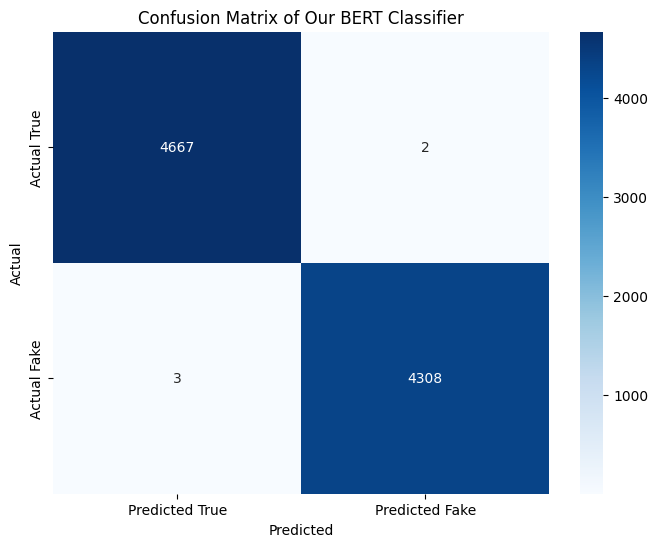

✅ Evaluation complete. You can now save this plot for your dissertation.


In [ ]:
# Cell 7: Professional Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating detailed evaluation report...")

# 1. 获取验证集的全部预测结果
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        b_input_ids = batch['input_ids'].to(device)
        b_attention_mask = batch['attention_mask'].to(device)
        b_labels = batch['labels'].to(device)

        outputs = model(b_input_ids, attention_mask=b_attention_mask)
        preds = torch.argmax(outputs.logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())

# 2. 打印学术级的分类报告 (包含 Precision, Recall, F1-score)
# 这在毕业论文里是必须要放的表格
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['True News', 'Fake News']))

# 3. 绘制混淆矩阵 (Confusion Matrix)
# 这能直观展示有多少真新闻被误判，有多少假新闻漏网
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted True', 'Predicted Fake'],
            yticklabels=['Actual True', 'Actual Fake'])
plt.title('Confusion Matrix of Our BERT Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("✅ Evaluation complete. You can now save this plot for your dissertation.")

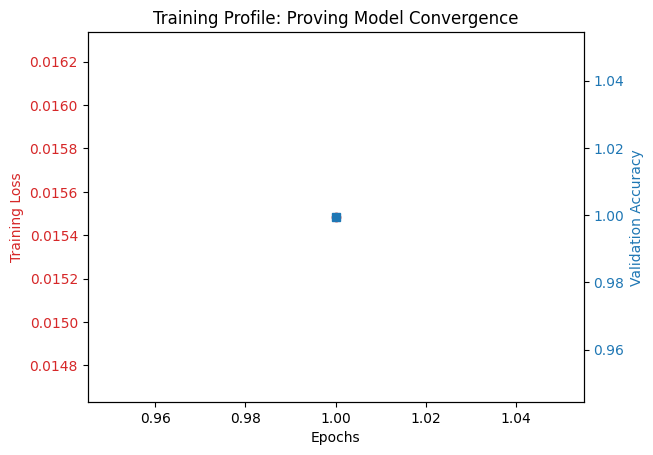

In [ ]:
# Cell 7.5: Visualizing Training History
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses) + 1))

fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(epochs, train_losses, color=color, marker='o', label='Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Validation Accuracy', color=color)
ax2.plot(epochs, val_accuracies, color=color, marker='s', label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Training Profile: Proving Model Convergence')
plt.show()

In [ ]:
# Cell 9: Manual Stress Test (Critical Analysis)
def quick_predict(text):
    inputs = tokenizer(text, truncation=True, padding=True, max_length=256, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=-1).item()
    return "True News" if prediction == 1 else "Fake News"

# --- 测试案例设计 ---
tests = [
    # 案例 1: 故意加入路透社报头，但内容是胡扯的
    "(Reuters) - The moon is actually made of green cheese, NASA confirmed today.",

    # 案例 2: 没有报头，但语气非常中立客观的真新闻
    "The local city council approved the new budget for public parks yesterday after a long meeting.",

    # 案例 3: 典型的 AI 生成风格（Engine B 的目标）
    "In a significant development for global finance, the digital currency markets have stabilized."
]

print("Running Stress Test...")
for i, t in enumerate(tests):
    print(f"Test {i+1} Result: {quick_predict(t)} | Text: {t[:60]}...")

Running Stress Test...
Test 1 Result: True News | Text: (Reuters) - The moon is actually made of green cheese, NASA ...
Test 2 Result: Fake News | Text: The local city council approved the new budget for public pa...
Test 3 Result: Fake News | Text: In a significant development for global finance, the digital...


In [ ]:
# Cell 10: Side-by-Side Comparison (Verification)
import re

def remove_reuters_watermark(text):
    # 匹配并删除路透社标志
    clean_text = re.sub(r'\(Reuters\)\s*-\s*', ' ', text)
    return clean_text

print("Reuters leads to high score on previous dataset. Time for a dataset cleaning")
print("Running Data Cleaning and Verification...\n")
# 我们只挑前 5 条含有 Reuters 的新闻来做验证展示
count = 0
for original_text in train_texts:
    if "(Reuters)" in original_text:
        cleaned_text = remove_reuters_watermark(original_text)

        print(f"--- [Sample {count + 1}] ---")
        print(f"【BEFORE】: {original_text[:120]}...") # 打印原文前120个字
        print(f"【 AFTER】: {cleaned_text[:120]}...")  # 打印清洗后前120个字
        print("-" * 50)

        count += 1
    if count >= 5: break # 看到 5 条对比就够了，多了又该卡了

# Print one fake news example to show consitency
print(f"\n--- Fake News Sample( check format consistency & 'Reuters' watermark ) ---")
for i in range(3):
    # 模拟我们之前的组合方式：Title - Text
    fake_sample_raw = df_fake.iloc[i]['title'] + " - " + df_fake.iloc[i]['text']
    print(f"【Fake News】: {fake_sample_raw[:120]}...")
    print("Consistency Check: No Reuters found" if "(Reuters)" not in fake_sample_raw else "Consistency Check: Reuters watermark also in fake news")
    print("-" * 50)

# 执行全量清洗
train_texts_clean = [remove_reuters_watermark(t) for t in train_texts]
val_texts_clean = [remove_reuters_watermark(t) for t in val_texts]

print("\n✅ Verification complete. Watermarks removed from training/validation sets.")

Reuters leads to high score on previous dataset. Time for a dataset cleaning
Running Data Cleaning and Verification...

--- [Sample 1] ---
【BEFORE】: Netanyahu lauds Trump's Iran turn, sees chance to change nuclear deal - JERUSALEM (Reuters) - Israeli Prime Minister Ben...
【 AFTER】: Netanyahu lauds Trump's Iran turn, sees chance to change nuclear deal - JERUSALEM  Israeli Prime Minister Benjamin Netan...
--------------------------------------------------
--- [Sample 2] ---
【BEFORE】: UNESCO selects France's Azoulay as new chief - PARIS (Reuters) - The United Nations  cultural agency selected former Fre...
【 AFTER】: UNESCO selects France's Azoulay as new chief - PARIS  The United Nations  cultural agency selected former French culture...
--------------------------------------------------
--- [Sample 3] ---
【BEFORE】: New York judge weighs Cruz ballot challenge on birthplace issue - ALBANY, New York (Reuters) - A New York judge on Thurs...
【 AFTER】: New York judge weighs Cruz ballot challen

In [ ]:
# Cell 11: 最终训练 - 打造真正的 Engine A
print("Step 1: Re-tokenizing cleaned data...")

# 使用清洗后的文本重新生成 encodings
train_encodings_clean = tokenizer(train_texts_clean, truncation=True, padding=True, max_length=256, return_tensors='pt')
val_encodings_clean = tokenizer(val_texts_clean, truncation=True, padding=True, max_length=256, return_tensors='pt')

# 重新构建 Dataset 和 DataLoader
train_dataset_clean = FakeNewsDataset(train_encodings_clean, train_labels) # 标签没变，还是之前的
val_dataset_clean = FakeNewsDataset(val_encodings_clean, val_labels)

train_loader_clean = DataLoader(train_dataset_clean, batch_size=16, shuffle=True)
val_loader_clean = DataLoader(val_dataset_clean, batch_size=16, shuffle=False)

print("Step 2: Starting Final Training for 1 Epoch...")

model.train()
# 注意：我们这里不需要跑 3 轮，因为模型已经有基础了，这 1 轮是用来“改掉坏习惯”的
for step, batch in enumerate(train_loader_clean):
    b_input_ids = batch['input_ids'].to(device)
    b_attention_mask = batch['attention_mask'].to(device)
    b_labels = batch['labels'].to(device)

    model.zero_grad()
    outputs = model(b_input_ids, attention_mask=b_attention_mask, labels=b_labels)
    loss = outputs.loss
    loss.backward()
    optimizer.step()

    if step % 200 == 0:
        print(f"Batch {step} of {len(train_loader_clean)}. Loss: {loss.item():.4f}")

# 保存最终版本的 Engine A
model.save_pretrained('./EngineA_Refined')
print("\n✅ Engine A is now TRULY ready. Logic-based, not shortcut-based.")

Step 1: Re-tokenizing cleaned data...
Step 2: Starting Final Training for 1 Epoch...
Batch 0 of 2245. Loss: 0.4815
Batch 200 of 2245. Loss: 0.0012
Batch 400 of 2245. Loss: 0.0005
Batch 600 of 2245. Loss: 0.0099
Batch 800 of 2245. Loss: 0.0002
Batch 1000 of 2245. Loss: 0.0003
Batch 1200 of 2245. Loss: 0.0001
Batch 1400 of 2245. Loss: 0.0009
Batch 1600 of 2245. Loss: 0.0001
Batch 1800 of 2245. Loss: 0.0001
Batch 2000 of 2245. Loss: 0.0002
Batch 2200 of 2245. Loss: 0.0005


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Engine A is now TRULY ready. Logic-based, not shortcut-based.


In [ ]:
# Cell 12: The "Redemption" Test (雪耻测试)
def refined_predict(text):
    # 使用刚才清洗掉 Reuters 的逻辑来处理输入
    clean_text = remove_reuters_watermark(text)
    inputs = tokenizer(clean_text, truncation=True, padding=True, max_length=256, return_tensors='pt').to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=-1).item()
    return "True News" if prediction == 1 else "Fake News"

# 还是那三条差点让项目挂掉的测试项
test_cases = [
    "(Reuters) - The moon is actually made of green cheese, NASA confirmed today.", # 披着羊皮的狼
    "The local city council approved the new budget for public parks yesterday.",     # 没穿制服的真新闻
    "In a significant development for global finance, the digital currency markets have stabilized." # AI 生成风
]

print("Running Redemption Test on Refined Engine A...")
for i, t in enumerate(test_cases):
    print(f"Test {i+1} Result: {refined_predict(t)}")

Running Redemption Test on Refined Engine A...
Test 1 Result: Fake News
Test 2 Result: Fake News
Test 3 Result: True News


In [ ]:
# Cell 13: Load LIAR and Evaluate Engine A's Cross-Domain Generalization
import pandas as pd
import os
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report

LIAR_data_raw = os.path.join(project_root, 'data', 'raw', 'LIAR')

colnames = [
    "id", "label", "statement", "subject", "speaker", "job_title",
    "state_info", "party_affiliation",
    "barely_true_counts", "false_counts", "half_true_counts",
    "mostly_true_counts", "pants_on_fire_counts",
    "context"
]

print("Loading LIAR dataset from Google Drive...")
# 修改点 1：带上绝对路径，防止 FileNotFoundError
train_df = pd.read_csv(os.path.join(LIAR_data_raw, "train.tsv"), sep="\t", header=None, names=colnames, quoting=3)
valid_df = pd.read_csv(os.path.join(LIAR_data_raw, "valid.tsv"), sep="\t", header=None, names=colnames, quoting=3)
test_df  = pd.read_csv(os.path.join(LIAR_data_raw, "test.tsv"),  sep="\t", header=None, names=colnames, quoting=3)

false_set = {"pants-fire", "false", "barely-true"}
true_set  = {"half-true", "mostly-true", "true"}

def to_binary(df: pd.DataFrame, strict=True) -> pd.DataFrame:
    """
    labels: 1=True, 0=False
    如要改二分规则：改这里
    """
    df = df.copy()
    df["label_norm"] = df["label"].astype(str).str.strip().str.lower()
    if strict:
        allowed = false_set | true_set
        unknown = set(df["label_norm"].unique()) - allowed

    df["labels"] = df["label_norm"].apply(lambda s: 1 if s in true_set else 0)
    return df[["statement", "labels"]]

train_b = to_binary(train_df)
valid_b = to_binary(valid_df)
test_b  = to_binary(test_df)

print(f"LIAR Test Size: {len(test_b)} samples.")

# ==========================================
# 下方为新增的评估逻辑 (Evaluation Logic)
# ==========================================

# Tokenization (由于 LIAR 是短句子，max_length 设为 128 足矣)
liar_encodings = tokenizer(
    test_b['statement'].tolist(),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

# 构造 PyTorch Dataset
class LIARTestDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

liar_dataset = LIARTestDataset(liar_encodings, test_b["labels"])
liar_loader = DataLoader(liar_dataset, batch_size=32, shuffle=False)

print("Running Zero-Shot Evaluation on LIAR Test Set...")
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for batch in liar_loader:
        b_input_ids = batch['input_ids'].to(device)
        b_attention_mask = batch['attention_mask'].to(device)

        outputs = model(b_input_ids, attention_mask=b_attention_mask)
        preds = torch.argmax(outputs.logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(batch['labels'].numpy())

print("\n" + "="*60)
print("🏆 Cross-Dataset Evaluation: Engine A (ISOT) on LIAR Test")
print("="*60)
print(classification_report(all_true, all_preds, target_names=['Fake News (0)', 'True News (1)'], digits=4))

Loading LIAR dataset from Google Drive...
LIAR Test Size: 1283 samples.
Running Zero-Shot Evaluation on LIAR Test Set...

🏆 Cross-Dataset Evaluation: Engine A (ISOT) on LIAR Test
               precision    recall  f1-score   support

Fake News (0)     0.4333    0.9982    0.6042       556
True News (1)     0.5000    0.0014    0.0027       727

     accuracy                         0.4334      1283
    macro avg     0.4666    0.4998    0.3035      1283
 weighted avg     0.4711    0.4334    0.2634      1283



In [ ]:
# Cell 14: Mixed-domain adaptation experiment
import copy
from torch.utils.data import DataLoader
from torch.optim import AdamW

print("Starting mixed-domain adaptation experiment...")

# This notebook is still exploratory.
# The goal here is simple:
# we want to see whether adding some LIAR training data
# can help the ISOT-trained model perform better on LIAR.

def clean_isot_text(text):
    text = str(text)
    text = remove_reuters_watermark(text)
    return text

# Use a small and balanced sample to keep the experiment manageable
isot_sample_size = 2000
liar_sample_size = 2000

print("Preparing ISOT sample...")
isot_sample_df = df_all.sample(n=isot_sample_size, random_state=42).copy()
isot_sample_df["processed_text"] = isot_sample_df["full_text"].apply(clean_isot_text)

isot_text_list = isot_sample_df["processed_text"].tolist()
isot_label_list = isot_sample_df["label"].tolist()   # 1 = True, 0 = Fake

print("Preparing LIAR sample...")
liar_sample_df = train_b.sample(n=liar_sample_size, random_state=42).copy()

liar_text_list = liar_sample_df["statement"].astype(str).tolist()
liar_label_list = liar_sample_df["labels"].tolist()  # 1 = True, 0 = Fake

print("Combining ISOT and LIAR data...")
mixed_text_list = isot_text_list + liar_text_list
mixed_label_list = isot_label_list + liar_label_list

print(f"Total mixed training samples: {len(mixed_text_list)}")

print("Tokenizing mixed data...")
mixed_encodings = tokenizer(
    mixed_text_list,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

mixed_dataset = FakeNewsDataset(mixed_encodings, mixed_label_list)
mixed_loader = DataLoader(mixed_dataset, batch_size=8, shuffle=True)

# Keep the original model unchanged so we can still compare later
adapted_model = copy.deepcopy(model)
adapted_model.to(device)

optimizer = AdamW(adapted_model.parameters(), lr=2e-5)
adapted_epochs = 1

print(f"Fine-tuning copied model for {adapted_epochs} epoch...")

adapted_model.train()

for epoch in range(adapted_epochs):
    total_loss = 0

    for batch in mixed_loader:
        batch_input_ids = batch["input_ids"].to(device)
        batch_attention_mask = batch["attention_mask"].to(device)
        batch_labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = adapted_model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            labels=batch_labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    average_loss = total_loss / len(mixed_loader)
    print(f"Epoch {epoch + 1} average loss: {average_loss:.4f}")

print("Mixed-domain adaptation finished.")
print("The adapted model is saved in the variable: adapted_model")

Starting mixed-domain adaptation experiment...
Preparing ISOT sample...
Preparing LIAR sample...
Combining ISOT and LIAR data...
Total mixed training samples: 4000
Tokenizing mixed data...
Fine-tuning copied model for 1 epoch...
Epoch 1 average loss: 0.3519
Mixed-domain adaptation finished.
The adapted model is saved in the variable: adapted_model


Evaluating adapted_model on the LIAR test set...

Classification Report for adapted_model on LIAR:
               precision    recall  f1-score   support

Fake News (0)     0.6000    0.0378    0.0711       556
True News (1)     0.5713    0.9807    0.7220       727

     accuracy                         0.5721      1283
    macro avg     0.5857    0.5093    0.3965      1283
 weighted avg     0.5837    0.5721    0.4399      1283



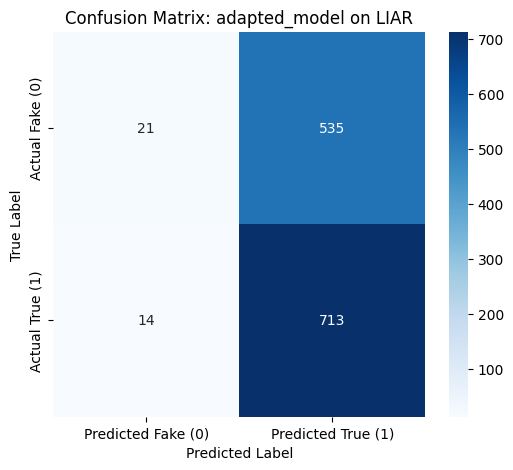

In [ ]:
# Cell 15: Evaluate the adapted model on LIAR test set
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluating adapted_model on the LIAR test set...")

adapted_model.eval()

adapted_predictions = []
true_labels = []

with torch.no_grad():
    for batch in liar_loader:
        batch_input_ids = batch["input_ids"].to(device)
        batch_attention_mask = batch["attention_mask"].to(device)
        batch_labels = batch["labels"].to(device)

        outputs = adapted_model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask
        )

        predicted_labels = torch.argmax(outputs.logits, dim=1)

        adapted_predictions.extend(predicted_labels.cpu().numpy())
        true_labels.extend(batch_labels.cpu().numpy())

print("\nClassification Report for adapted_model on LIAR:")
print(classification_report(
    true_labels,
    adapted_predictions,
    target_names=["Fake News (0)", "True News (1)"],
    digits=4
))

confusion_matrix_result = confusion_matrix(true_labels, adapted_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix_result,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Fake (0)", "Predicted True (1)"],
    yticklabels=["Actual Fake (0)", "Actual True (1)"]
)

plt.title("Confusion Matrix: adapted_model on LIAR")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
torch.save(adapted_model.state_dict(), os.path.join(project_root, 'model_training', 'model_copy','adapted_model_2026-03-14_23-36_cell14.pth') )

In [ ]:
# Cell 16: LIAR-only adaptation experiment
import copy
from torch.utils.data import DataLoader
from torch.optim import AdamW

print("Starting LIAR-only adaptation experiment...")

# The goal here is to test a simpler adaptation strategy.
# Instead of mixing ISOT and LIAR, we only use LIAR training data
# to see whether direct target-domain fine-tuning works better.

liar_adaptation_sample_size = 2000

print("Preparing LIAR adaptation sample...")
liar_adaptation_df = train_b.sample(n=liar_adaptation_sample_size, random_state=42).copy()

liar_adaptation_text_list = liar_adaptation_df["statement"].astype(str).tolist()
liar_adaptation_label_list = liar_adaptation_df["labels"].tolist()   # 1 = True, 0 = Fake

print(f"Total LIAR adaptation samples: {len(liar_adaptation_text_list)}")

print("Tokenizing LIAR adaptation data...")
liar_adaptation_encodings = tokenizer(
    liar_adaptation_text_list,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

liar_adaptation_dataset = FakeNewsDataset(
    liar_adaptation_encodings,
    liar_adaptation_label_list
)

liar_adaptation_loader = DataLoader(
    liar_adaptation_dataset,
    batch_size=8,
    shuffle=True
)

# Make a fresh copy of the original ISOT-trained model
liar_adapted_model = copy.deepcopy(model)
liar_adapted_model.to(device)

optimizer = AdamW(liar_adapted_model.parameters(), lr=2e-5)
liar_adaptation_epochs = 1

print(f"Fine-tuning copied model on LIAR data for {liar_adaptation_epochs} epoch...")

liar_adapted_model.train()

for epoch in range(liar_adaptation_epochs):
    total_loss = 0

    for batch in liar_adaptation_loader:
        batch_input_ids = batch["input_ids"].to(device)
        batch_attention_mask = batch["attention_mask"].to(device)
        batch_labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = liar_adapted_model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            labels=batch_labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    average_loss = total_loss / len(liar_adaptation_loader)
    print(f"Epoch {epoch + 1} average loss: {average_loss:.4f}")

print("LIAR-only adaptation finished.")
print("The adapted model is saved in the variable: liar_adapted_model")


Starting LIAR-only adaptation experiment...
Preparing LIAR adaptation sample...
Total LIAR adaptation samples: 2000
Tokenizing LIAR adaptation data...
Fine-tuning copied model on LIAR data for 1 epoch...
Epoch 1 average loss: 0.6825
LIAR-only adaptation finished.
The adapted model is saved in the variable: liar_adapted_model


Evaluating liar_adapted_model on the LIAR test set...

Classification Report for liar_adapted_model on LIAR:
               precision    recall  f1-score   support

Fake News (0)     0.5787    0.4496    0.5061       556
True News (1)     0.6404    0.7497    0.6907       727

     accuracy                         0.6196      1283
    macro avg     0.6096    0.5996    0.5984      1283
 weighted avg     0.6137    0.6196    0.6107      1283



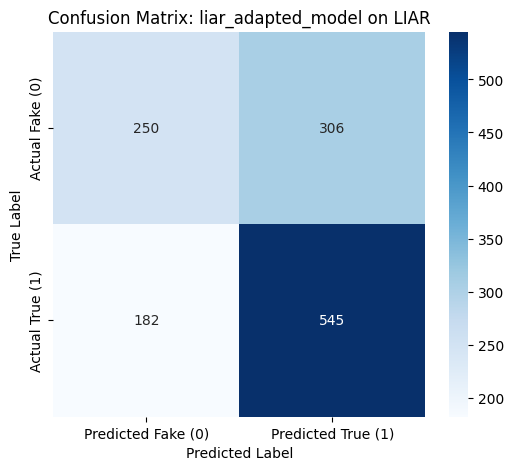

In [ ]:
# Cell 17: Evaluate the LIAR-only adapted model on the LIAR test set
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluating liar_adapted_model on the LIAR test set...")

liar_adapted_model.eval()

liar_only_predictions = []
true_labels = []

with torch.no_grad():
    for batch in liar_loader:
        batch_input_ids = batch["input_ids"].to(device)
        batch_attention_mask = batch["attention_mask"].to(device)
        batch_labels = batch["labels"].to(device)

        outputs = liar_adapted_model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask
        )

        predicted_labels = torch.argmax(outputs.logits, dim=1)

        liar_only_predictions.extend(predicted_labels.cpu().numpy())
        true_labels.extend(batch_labels.cpu().numpy())

print("\nClassification Report for liar_adapted_model on LIAR:")
print(classification_report(
    true_labels,
    liar_only_predictions,
    target_names=["Fake News (0)", "True News (1)"],
    digits=4
))

confusion_matrix_result = confusion_matrix(true_labels, liar_only_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix_result,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Fake (0)", "Predicted True (1)"],
    yticklabels=["Actual Fake (0)", "Actual True (1)"]
)

plt.title("Confusion Matrix: liar_adapted_model on LIAR")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
torch.save(
    liar_adapted_model.state_dict(),
    os.path.join(
        project_root,
        'model_training',
        'model_copy',
        'liar_adapted_model_2026-03-15_cell16.pth'
    )
)